In [1]:
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install pandas
!pip install folium


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

In [3]:
df = pd.read_csv(r"C:\Users\User\Desktop\f43\US_Accidents_March23.csv")
print(df.shape)
df.head()

(7728394, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [4]:
# Convert datetime columns
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['Hour'] = df['Start_Time'].dt.hour
df['Day'] = df['Start_Time'].dt.day_name()
df['Month'] = df['Start_Time'].dt.month
df = df.dropna(subset=['Start_Lat', 'Start_Lng'])
print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (7728394, 49)


**Accidents by Time of Day**

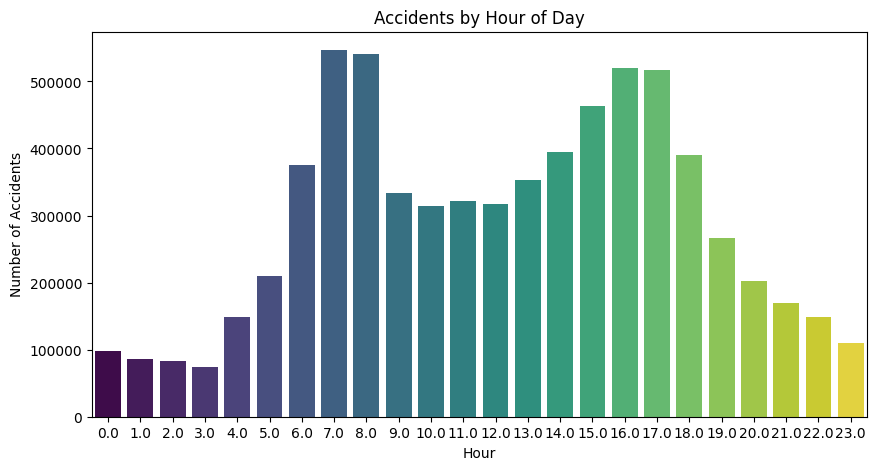

In [5]:
plt.figure(figsize=(10,5))
sns.countplot(
    x='Hour',
    data=df,
    hue='Hour',
    palette='viridis',
    order=sorted(df['Hour'].dropna().unique()),
    legend=False
)
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.show()

**Accidents by Day of Week**

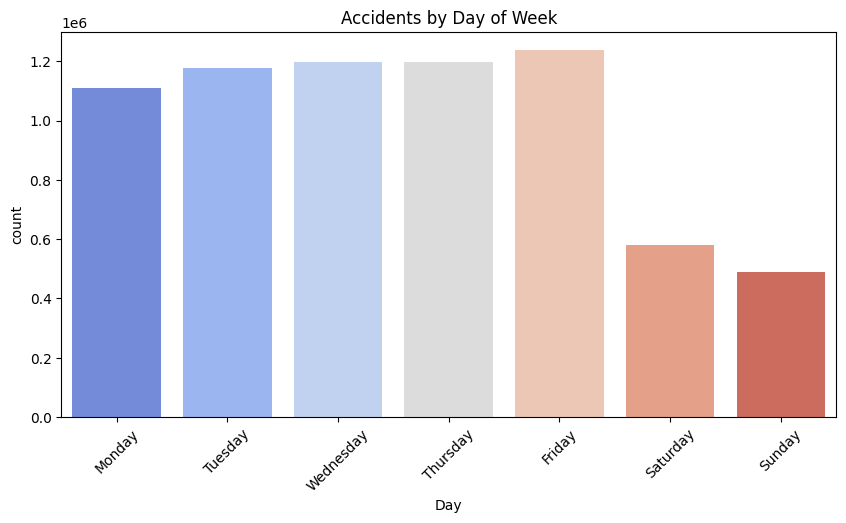

In [6]:
plt.figure(figsize=(10,5))
sns.countplot(
    x='Day',
    data=df,
    hue='Day',
    palette='coolwarm',
    order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
    legend=False
)
plt.title("Accidents by Day of Week")
plt.xticks(rotation=45)
plt.show()

**Weather Condition Analysis**

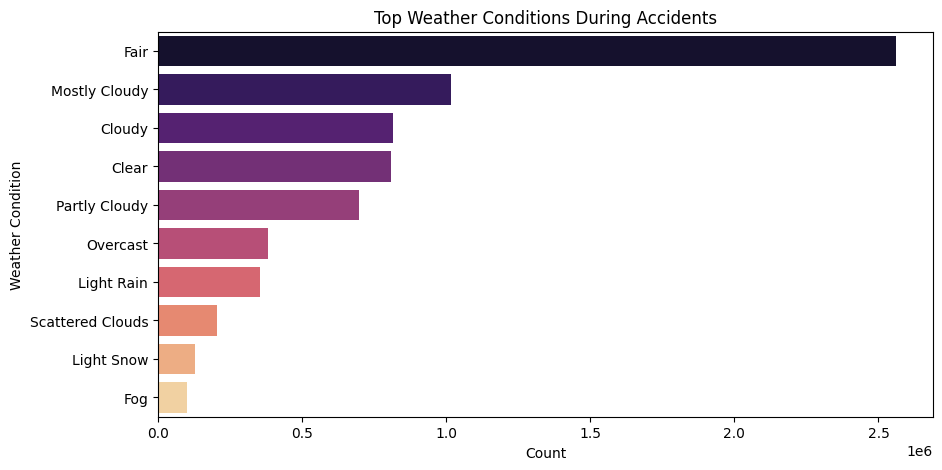

In [11]:
top_weather = df['Weather_Condition'].value_counts().head(10)
top_weather
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_weather.values,
    y=top_weather.index,
    hue=top_weather.index,
    palette='magma',
    legend=False
)
plt.title("Top Weather Conditions During Accidents")
plt.xlabel("Count")
plt.ylabel("Weather Condition")
plt.show()

**Road Condition Factors**

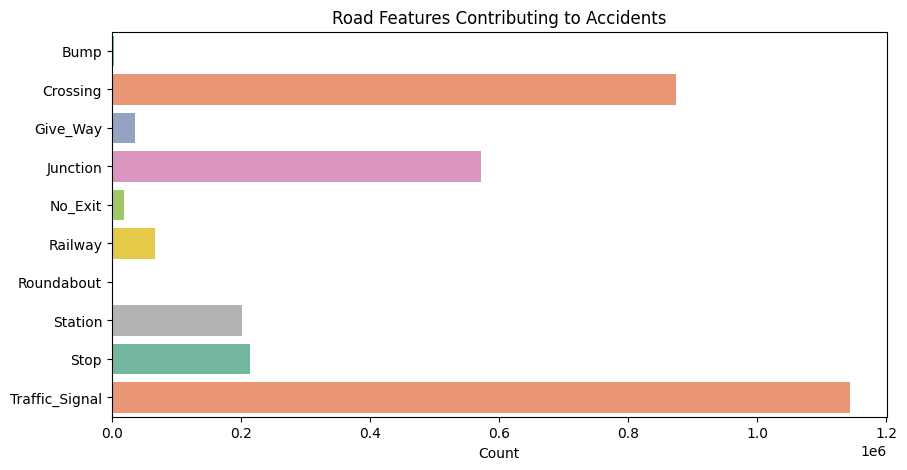

In [12]:
features = ['Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
            'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Signal']

counts = [df[feature].sum() for feature in features]
plt.figure(figsize=(10,5))
sns.barplot(
    x=counts,
    y=features,
    hue=features,
    palette='Set2',
    legend=False
)
plt.title("Road Features Contributing to Accidents")
plt.xlabel("Count")
plt.show()

**Accident Severity Distribution**

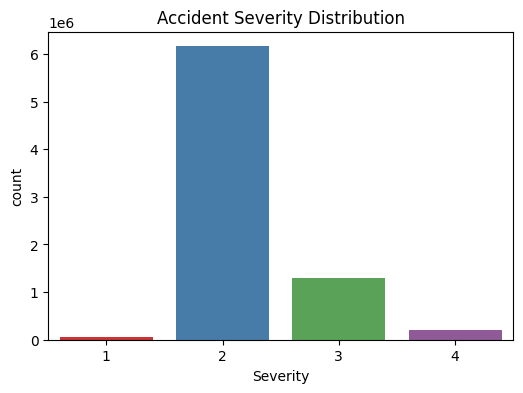

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='Severity',
    data=df,
    hue='Severity',
    palette='Set1',
    legend=False
)

plt.title("Accident Severity Distribution")
plt.show()

In [14]:
hotspot_df = df.dropna(subset=['Start_Lat', 'Start_Lng'])
hotspot_df = hotspot_df.sample(n=10000, random_state=42)
m = folium.Map(location=[37.77, -122.42], zoom_start=5)
heat_data = list(zip(hotspot_df['Start_Lat'], hotspot_df['Start_Lng']))
HeatMap(heat_data, radius=8, blur=12, max_zoom=10).add_to(m)
m